
Dressed energies:
-47.5624609863
-5.0000000000
 0.0000000000
 52.5624609863

Dressed frequency offsets nu:
-100.1249219725
-57.5624609863
-52.5624609863
-47.5624609863
-42.5624609863
-5.0000000000
 0.0000000000
 5.0000000000
 42.5624609863
 47.5624609863
 52.5624609863
 57.5624609863
 100.1249219725

Collapse operators:
s emission         nu = -100.12492197
a emission         nu = -57.56246099
s emission         nu = -52.56246099
s emission         nu = -47.56246099
a emission         nu = -42.56246099
a emission         nu = -5.00000000
s emission         nu =  0.00000000
a emission         nu =  5.00000000
a emission         nu =  42.56246099
s emission         nu =  47.56246099
s emission         nu =  52.56246099
a emission         nu =  57.56246099
s emission         nu =  100.12492197

|| [H_rot, rho_ss] || = 1.3830302897219153e-14
Detector reconstruction error = 1.5292886642652633e-15
Steady-state intensity = 0.9999999999999998


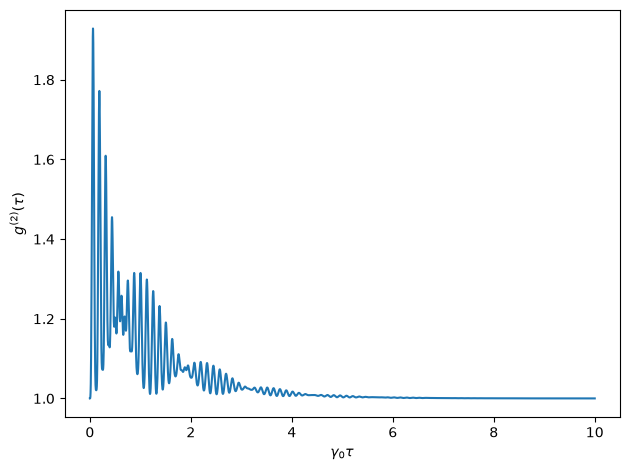


g2(0) = 1.0000000000000004
g2(final) = 1.0000741962138038


In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


# ============================================================
# PARAMETERS
# All frequencies/rates are in the same inverse-time units.
# We use gamma0 = 1 as the unit.
# ============================================================

gamma0  = 1.0
gamma12 = 0.30 * gamma0       # collective decay
J       = 5.0  * gamma0       # dipole-dipole coupling Omega_12
Omega   = 50.0 * gamma0       # Rabi frequency
Delta   = 0.0  * gamma0       # omega_0 - omega_L

# Optical carrier.  It is NOT put into the Hamiltonian.
# It matters only if bath rates depend appreciably on frequency.
omega_L = 1.0e8 * gamma0

# Optical thermal occupation. Usually essentially zero.
nbar0 = 0.0

# Detector relative phase:
# D = sigma_1^- + exp(-i phi_det) sigma_2^-
#
# phi_det = 0 corresponds to your D1 + D2 model.
phi_det = 0.0


# ============================================================
# TWO-QUBIT OPERATORS
# ============================================================

I = qt.qeye(2)

sm1 = qt.tensor(qt.sigmam(), I)
sm2 = qt.tensor(I, qt.sigmam())

sp1 = sm1.dag()
sp2 = sm2.dag()

sx1 = qt.tensor(qt.sigmax(), I)
sx2 = qt.tensor(I, qt.sigmax())

sz1 = qt.tensor(qt.sigmaz(), I)
sz2 = qt.tensor(I, qt.sigmaz())


# ============================================================
# ROTATING-FRAME SYSTEM HAMILTONIAN
# ============================================================

H_rot = (
      0.5 * Delta * (sz1 + sz2)
    + 0.5 * Omega * (sx1 + sx2)
    + J * (sp1 * sm2 + sm1 * sp2)
)


# ============================================================
# HELPER: convert a 1x1 Qobj or scalar to complex
# ============================================================

def scalar(x):
    if isinstance(x, qt.Qobj):
        return x.full()[0, 0]
    return complex(x)


# ============================================================
# DRESSED DECOMPOSITION
#
# sigma_j^- = sum_nu A_j(nu)
#
# with
#
#   exp(+i H t) A_j(nu) exp(-i H t)
#          = exp(-i nu t) A_j(nu)
#
# Thus nu = E_b - E_a for |b> -> |a>.
# ============================================================

def dressed_components(H, operators,
                       freq_tol=1e-9,
                       matrix_tol=1e-12):

    energies, states = H.eigenstates()

    energies = np.asarray(energies, dtype=float)

    projectors = [
        ket * ket.dag()
        for ket in states
    ]

    dim = len(energies)

    # Find transitions that actually occur in at least one operator.
    transitions = []

    for a in range(dim):
        for b in range(dim):

            nonzero = False

            for op in operators:
                z = scalar(states[a].dag() * op * states[b])

                if abs(z) > matrix_tol:
                    nonzero = True
                    break

            if nonzero:
                nu = energies[b] - energies[a]
                transitions.append((nu, a, b))

    # --------------------------------------------------------
    # Group numerically equal Bohr frequencies.
    # --------------------------------------------------------

    raw_freqs = sorted([x[0] for x in transitions])

    frequency_groups = []

    for nu in raw_freqs:

        if len(frequency_groups) == 0:
            frequency_groups.append([nu])

        else:
            center = np.mean(frequency_groups[-1])

            if abs(nu - center) < freq_tol:
                frequency_groups[-1].append(nu)

            else:
                frequency_groups.append([nu])

    frequencies = [
        float(np.mean(group))
        for group in frequency_groups
    ]

    # Initialize A_j(nu)
    components = {
        nu: [0 * op for op in operators]
        for nu in frequencies
    }

    # Assign each matrix element to the appropriate frequency.
    for nu_raw, a, b in transitions:

        nu = min(
            frequencies,
            key=lambda x: abs(x - nu_raw)
        )

        for j, op in enumerate(operators):
            components[nu][j] += (
                projectors[a] * op * projectors[b]
            )

    return energies, states, components


energies, dressed_states, A = dressed_components(
    H_rot,
    [sm1, sm2]
)


print("\nDressed energies:")
for E in energies:
    print(f"{E: .10f}")

print("\nDressed frequency offsets nu:")
for nu in sorted(A.keys()):
    print(f"{nu: .10f}")


# ============================================================
# BATH MODEL
#
# IMPORTANT:
# The physical emitted photon frequency is
#
#       omega_photon = omega_L + nu
#
# not simply nu.
#
# Here gamma_ij is assumed essentially constant across the
# Rabi/dipole sidebands.
# ============================================================

def bath_rates(nu):

    omega_photon = omega_L + nu

    # In this approximation these are constant.
    g0  = gamma0
    g12 = gamma12
    nb  = nbar0

    # You can later replace these by
    # g0(omega_photon), g12(omega_photon), nbar(omega_photon).

    return g0, g12, nb


# ============================================================
# BUILD GLOBAL / DRESSED GKSL COLLAPSE OPERATORS
#
# For each dressed frequency:
#
#   B_s(nu) = [A1(nu) + A2(nu)] / sqrt(2)
#   B_a(nu) = [A1(nu) - A2(nu)] / sqrt(2)
#
# Rates:
#
#   Gamma_s = gamma0 + gamma12
#   Gamma_a = gamma0 - gamma12
# ============================================================

def make_dressed_collapse_operators(A,
                                    operator_tol=1e-12):

    c_ops = []
    labels = []

    for nu in sorted(A.keys()):

        A1, A2 = A[nu]

        g0, g12, nb = bath_rates(nu)

        gamma_s = g0 + g12
        gamma_a = g0 - g12

        if gamma_s < -1e-12 or gamma_a < -1e-12:
            raise ValueError(
                "Collective decay matrix is not positive."
            )

        gamma_s = max(gamma_s, 0.0)
        gamma_a = max(gamma_a, 0.0)

        Bs = (A1 + A2) / np.sqrt(2.0)
        Ba = (A1 - A2) / np.sqrt(2.0)

        # ----------------------------
        # symmetric emission
        # ----------------------------
        if gamma_s > 0 and Bs.norm() > operator_tol:

            C = np.sqrt(gamma_s * (nb + 1.0)) * Bs
            c_ops.append(C)
            labels.append(("s emission", nu))

            if nb > 0:
                C = np.sqrt(gamma_s * nb) * Bs.dag()
                c_ops.append(C)
                labels.append(("s absorption", nu))

        # ----------------------------
        # antisymmetric emission
        # ----------------------------
        if gamma_a > 0 and Ba.norm() > operator_tol:

            C = np.sqrt(gamma_a * (nb + 1.0)) * Ba
            c_ops.append(C)
            labels.append(("a emission", nu))

            if nb > 0:
                C = np.sqrt(gamma_a * nb) * Ba.dag()
                c_ops.append(C)
                labels.append(("a absorption", nu))

    return c_ops, labels


c_ops, collapse_labels = make_dressed_collapse_operators(A)

print("\nCollapse operators:")
for lab, nu in collapse_labels:
    print(f"{lab:16s}   nu = {nu: .8f}")


# ============================================================
# STEADY STATE
#
# We can solve the rotating-frame steady state algebraically.
# No long time integration is necessary.
# ============================================================

rho_ss = qt.steadystate(H_rot, c_ops)


# For a fully secular dressed master equation, rho_ss should
# commute with H_rot, apart from numerical error / degeneracy.

comm = H_rot * rho_ss - rho_ss * H_rot

print("\n|| [H_rot, rho_ss] || =", comm.norm())


# ============================================================
# DETECTOR
#
# D = D1 + D2, with optional propagation phase.
#
# Decompose D into exactly the SAME dressed frequencies.
# ============================================================

detector_components = {}

for nu, (A1, A2) in A.items():

    Dnu = A1 + np.exp(-1j * phi_det) * A2

    if Dnu.norm() > 1e-12:
        detector_components[nu] = Dnu


# Reconstruct D at t = 0.
D = 0 * sm1

for Dnu in detector_components.values():
    D += Dnu


# Check against original detector.
D_bare = sm1 + np.exp(-1j * phi_det) * sm2

print("Detector reconstruction error =",
      (D - D_bare).norm())


# ============================================================
# DETECTOR IN THE INTERACTION PICTURE OF H_rot
#
# D_I(t) = sum_nu exp(-i nu t) D(nu)
#
# The common optical factor exp(-i omega_L t) has been dropped,
# since it cancels from normally ordered intensity correlations.
# ============================================================

def D_interaction(t):

    Dt = 0 * D

    for nu, Dnu in detector_components.items():
        Dt += np.exp(-1j * nu * t) * Dnu

    return Dt


# ============================================================
# STEADY-STATE INTENSITY
# ============================================================

I_ss = np.real(
    qt.expect(D.dag() * D, rho_ss)
)

print("Steady-state intensity =", I_ss)


# ============================================================
# g2 USING QRT IN THE SECOND INTERACTION PICTURE
#
# rho_c(0) = D rho_ss D^\dagger
#
# IMPORTANT:
# rho_c is UNNORMALIZED.
#
# We evolve with H = 0.
#
# Therefore mesolve sees only the slow dissipative dynamics.
# ============================================================

rho_cond_0 = D * rho_ss * D.dag()


# Choose whatever delay range you want.
#
# Although mesolve does NOT need to resolve 1/Omega internally,
# your OUTPUT tlist must resolve Rabi oscillations if you want
# to plot them.

tau_max = 10.0 / gamma0
Ntau = 5000

taus = np.linspace(0.0, tau_max, Ntau)


H_slow = 0 * H_rot


result = qt.mesolve(
    H_slow,
    rho_cond_0,
    taus,
    c_ops=c_ops,
    e_ops=None,
    options={
        "store_states": True,
        "normalize_output": False,
        "progress_bar": False,
    }
)


# ============================================================
# Evaluate the second detection at time tau:
#
# G2(tau)
# =
# Tr[
# D_I^\dagger(tau) D_I(tau) rho_cond^I(tau)
# ]
# ============================================================

G2 = np.zeros(len(taus))

for k, (tau, rho_tau) in enumerate(zip(taus, result.states)):

    Dt = D_interaction(tau)

    G2[k] = np.real(
        qt.expect(Dt.dag() * Dt, rho_tau)
    )


g2 = G2 / I_ss**2


# ============================================================
# PLOT
# ============================================================

plt.figure()

plt.plot(taus * gamma0, g2)

plt.xlabel(r"$\gamma_0 \tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")

plt.tight_layout()
plt.show()


print("\ng2(0) =", g2[0])
print("g2(final) =", g2[-1])